# Bank Churn Intelligence - Notebook 02: Exploratory Data Analysis

## Objective
Visually investigate why customers are leaving
7 analysis covering geography, products, complaints, age, balance, card type and engagement - each with a business insight.

In [1]:
import pandas as pd
import numpy as nmp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

#Load Data
df = pd.read_csv('../data/raw/Customer-Churn-Records.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Churned: {df['Exited'].sum():,} | Retained: {(df['Exited']==0).sum():,}")

Loaded: 10,000 rows x 18 columns
Churned: 2,038 | Retained: 7,962


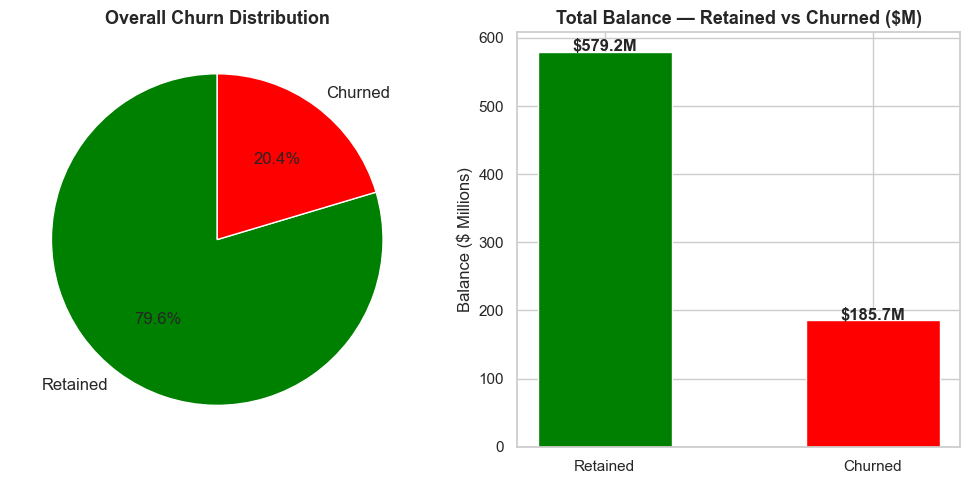

Chart saved to dashboard folder


In [2]:
# Analysis 1 - Overall Churn Rate 
fig, axes = plt.subplots(1,2, figsize=(10,5))

#Pie Chart
churn_counts = df['Exited'].value_counts()
colors = ['Green', 'Red']
axes[0].pie(churn_counts, labels=['Retained','Churned'],
autopct='%1.1f%%', colors=colors, startangle=90,
textprops={'fontsize':12})
axes[0].set_title('Overall Churn Distribution')

# Balance lost vs retained
balance_summary = df.groupby('Exited')['Balance'].sum() / 1e6
bars = axes[1].bar(['Retained', 'Churned'], balance_summary.values,
                    color=['Green', 'Red'], width=0.5)
axes[1].set_title('Total Balance — Retained vs Churned ($M)')
axes[1].set_ylabel('Balance ($ Millions)')
for bar, val in zip(bars, balance_summary.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${val:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/01_overall_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to dashboard folder")

### Analysis 1 — Business Insight

**Finding:** 20.4% of customers churned — 1 in every 5 customers left the bank.

**Revenue impact:** $185M in customer deposits walked out the door.

**What the bank should do:** This is not a minor retention problem.
Losing $185M in deposits affects the bank's lending capacity and liquidity.
This needs board-level attention, not just a marketing campaign.

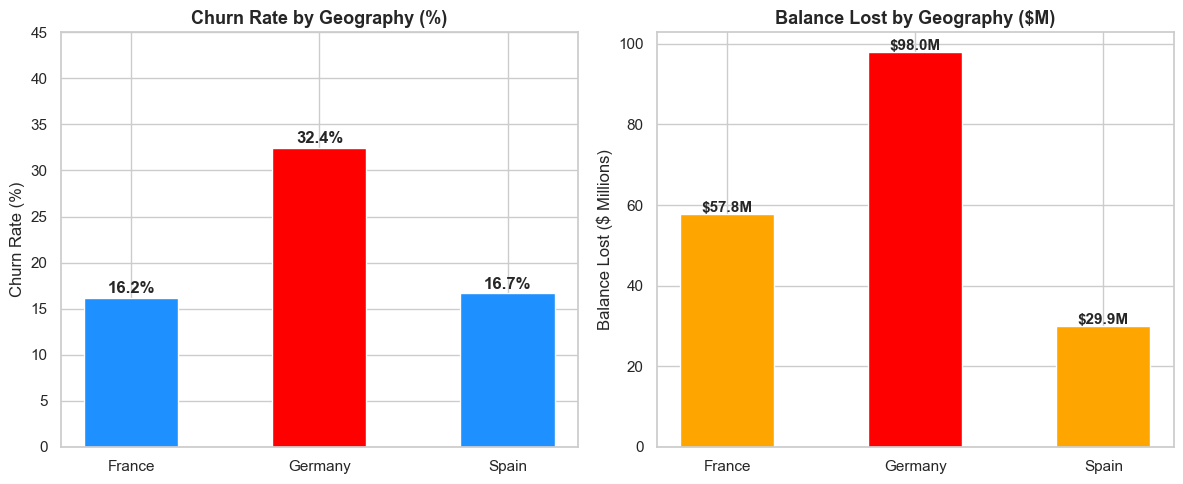

Chart saved.


In [3]:
# ANALYSIS 2: Geography — which country is the biggest problem?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
colors_geo = ['red' if v == geo_churn.max() else 'dodgerblue' 
              for v in geo_churn.values]
bars = axes[0].bar(geo_churn.index, geo_churn.values, color=colors_geo, width=0.5)
axes[0].set_title('Churn Rate by Geography (%)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 45)
for bar, val in zip(bars, geo_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Balance lost by geography
geo_balance = df[df['Exited']==1].groupby('Geography')['Balance'].sum() / 1e6
colors_bal = ['red' if v == geo_balance.max() else 'orange' 
              for v in geo_balance.values]
bars2 = axes[1].bar(geo_balance.index, geo_balance.values, color=colors_bal, width=0.5)
axes[1].set_title('Balance Lost by Geography ($M)')
axes[1].set_ylabel('Balance Lost ($ Millions)')
for bar, val in zip(bars2, geo_balance.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.1f}M', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../dashboard/02_geography_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Analysis 2 — Business Insight

**Finding:** Germany churns at ~32% — more than double France's rate (~16%).
Despite being only 25% of the customer base, Germany contributes
the largest share of balance lost.

**What the bank should do:** Germany is not a churn problem —
it is a country-specific crisis. Possible causes: a local competitor
offering better rates, a product that doesn't fit German market needs,
or a service quality gap in that region.

**Recommended action:** Conduct exit interviews specifically for
Germany customers. This needs a geo-targeted retention strategy,
not a blanket campaign.

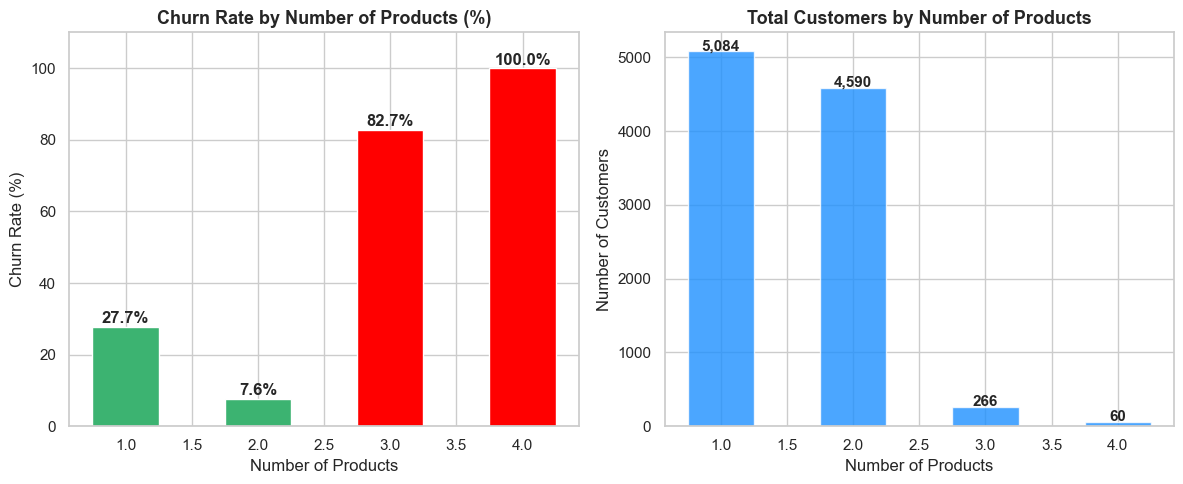

Chart saved.


In [4]:
# ANALYSIS 3: Number of products — the counter-intuitive finding
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by number of products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
colors_prod = ['mediumseagreen' if v < 50 else 'red' for v in prod_churn.values]
bars = axes[0].bar(prod_churn.index, prod_churn.values, color=colors_prod, width=0.5)
axes[0].set_title('Churn Rate by Number of Products (%)')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, prod_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Customer count by products — to show scale
prod_count = df.groupby('NumOfProducts')['Exited'].count()
axes[1].bar(prod_count.index, prod_count.values, 
            color='dodgerblue', width=0.5, alpha=0.8)
axes[1].set_title('Total Customers by Number of Products')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Number of Customers')
for bar, val in zip(axes[1].patches, prod_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../dashboard/03_products_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Analysis 3 — Business Insight

**Finding:** Customers with 3 or 4 products churn at 82–100%.
This is the most counter-intuitive finding in the dataset.

Common assumption: more products = more loyalty.
Reality: more products = more friction = faster exit.

**What the bank should do:** Stop cross-selling beyond 2 products
per customer without a relationship review first. Customers with 3+
products should be flagged for an immediate RM check-in call.
The bank is accidentally accelerating churn by selling more.

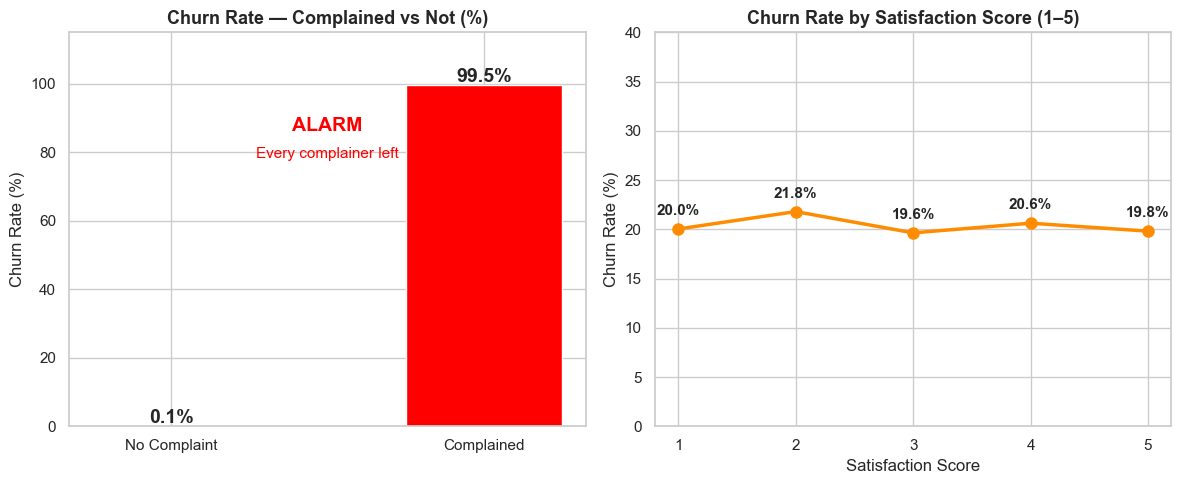

Chart saved.


In [5]:
# ANALYSIS 4: Complaint + Satisfaction — the most powerful finding
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Complaint vs churn
complain_churn = df.groupby('Complain')['Exited'].mean() * 100
bars = axes[0].bar(['No Complaint', 'Complained'], 
                    complain_churn.values,
                    color=['mediumseagreen', 'red'], width=0.5)
axes[0].set_title('Churn Rate — Complained vs Not (%)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 115)
for bar, val in zip(bars, complain_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=14)

# Add alarm text on chart
axes[0].text(0.5, 0.75, 'ALARM', transform=axes[0].transAxes,
             ha='center', fontsize=14, color='red', fontweight='bold')
axes[0].text(0.5, 0.68, 'Every complainer left', transform=axes[0].transAxes,
             ha='center', fontsize=11, color='red')

# Satisfaction score vs churn rate
sat_churn = df.groupby('Satisfaction Score')['Exited'].mean() * 100
axes[1].plot(sat_churn.index, sat_churn.values, 
             marker='o', color='darkorange', linewidth=2.5, markersize=8)
axes[1].set_title('Churn Rate by Satisfaction Score (1–5)')
axes[1].set_xlabel('Satisfaction Score')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_ylim(0, 40)
for x, y in zip(sat_churn.index, sat_churn.values):
    axes[1].annotate(f'{y:.1f}%', (x, y), 
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/04_complaint_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Analysis 4 — Business Insight

**Finding 1 — Complaint:** 99.5% of customers who complained, churned.
The bank retained virtually zero complaining customers.
Complaint = the last signal before a customer leaves.

**Finding 2 — Satisfaction Score:** Churn rate is nearly flat across
all satisfaction scores (1 to 5). A score of 1 and a score of 5
have almost the same churn rate.

**Critical implication:** Satisfaction surveys are not predicting
churn in this bank. Customers are leaving without expressing
dissatisfaction through the survey — they just leave silently.

The real early warning signal is NOT the satisfaction score.
It is engagement metrics: activity status, points earned, products held.
The bank is measuring the wrong thing.

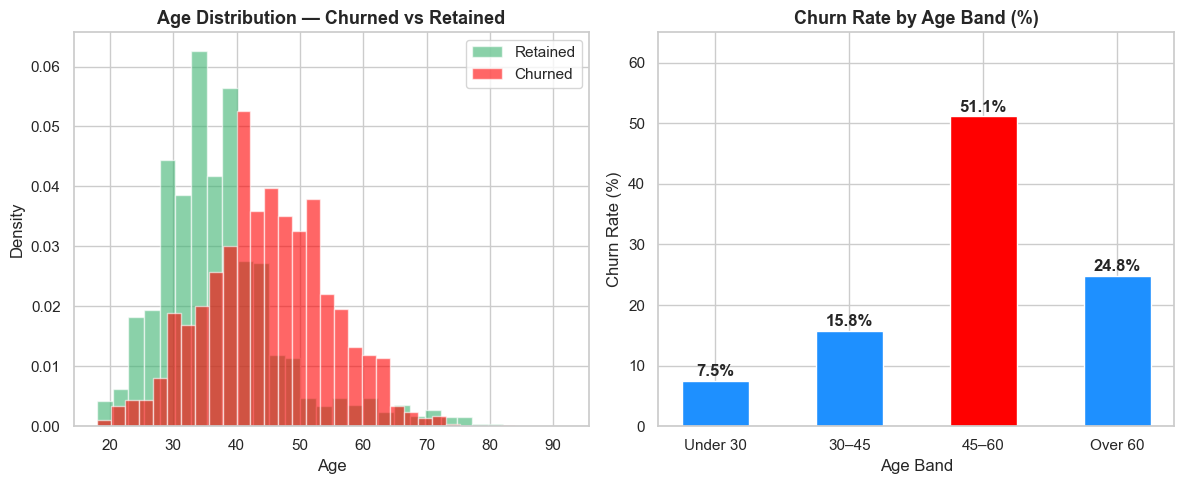

Chart saved.


In [6]:
# ANALYSIS 5: Age — who exactly is leaving?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution — churned vs retained
axes[0].hist(df[df['Exited']==0]['Age'], bins=30, alpha=0.6, 
             color='mediumseagreen', label='Retained', density=True)
axes[0].hist(df[df['Exited']==1]['Age'], bins=30, alpha=0.6, 
             color='red', label='Churned', density=True)
axes[0].set_title('Age Distribution — Churned vs Retained')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend()

# Churn rate by age band
df['Age_Band'] = pd.cut(df['Age'], 
                         bins=[0, 30, 45, 60, 100],
                         labels=['Under 30', '30–45', '45–60', 'Over 60'])
age_churn = df.groupby('Age_Band', observed=True)['Exited'].mean() * 100
colors_age = ['red' if v == age_churn.max() else 'dodgerblue' 
              for v in age_churn.values]
bars = axes[1].bar(age_churn.index, age_churn.values, 
                    color=colors_age, width=0.5)
axes[1].set_title('Churn Rate by Age Band (%)')
axes[1].set_xlabel('Age Band')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 65)
for bar, val in zip(bars, age_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../dashboard/05_age_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### Analysis 5 — Business Insight

**Finding:** The 45–60 age band churns at the highest rate — nearly 2×
the rate of customers under 30 or over 60.

This is the bank's most valuable customer segment — mid-career
professionals with the highest account balances and longest tenure.
Losing them is disproportionately expensive.

**What the bank should do:** Design a specific retention programme
for customers aged 45–60 — priority RM assignment, quarterly check-in
calls, exclusive product offers. This segment is too valuable to lose
to a competitor offering 0.5% better interest rate.

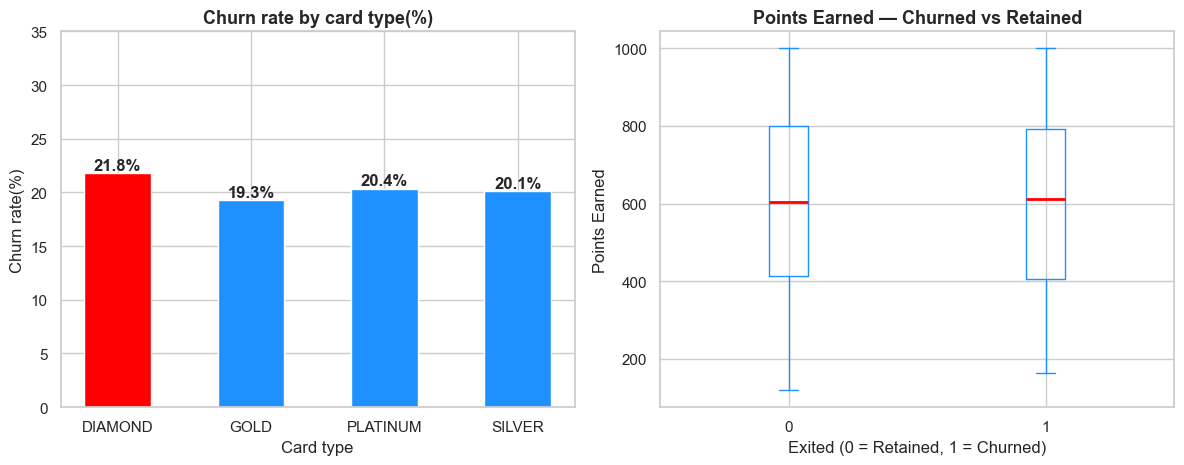

Chart saved.


In [7]:
# Analysis 6: Card Type + Points Earned - engagement signals
fig, axes = plt.subplots(1,2, figsize=(12, 5))

# Churn Rate by card type
card_churn = df.groupby('Card Type')['Exited'].mean() * 100
colors_card = ['Red' if v == card_churn.max() else 'Dodgerblue'
               for v in card_churn.values]

bars = axes[0].bar(card_churn.index, card_churn.values,
                   color = colors_card, width = 0.5)
axes[0].set_title('Churn rate by card type(%)')
axes[0].set_xlabel('Card type')
axes[0].set_ylabel('Churn rate(%)')
axes[0].set_ylim(0, 35)
for bar, val in zip(bars, card_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
    
# Points earned - churned vs retained boxplot
df.boxplot(column='Point Earned', by='Exited', ax=axes[1],
           boxprops=dict(color='Dodgerblue'),
           medianprops=dict(color='Red', linewidth=2),
           whiskerprops=dict(color='Dodgerblue'),
           capprops=dict(color='Dodgerblue'))
axes[1].set_title('Points Earned — Churned vs Retained')
axes[1].set_xlabel('Exited (0 = Retained, 1 = Churned)')
axes[1].set_ylabel('Points Earned')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../dashboard/06_card_points_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


### Analysis 6 — Business Insight

**Finding 1 — Card Type:** Churn rate is nearly equal across all card
types (Diamond, Gold, Silver, Platinum) — around 20–21%.
Card type alone does not predict churn.

**Finding 2 — Points Earned:** Churned and retained customers have
almost identical points distribution. Low engagement through
loyalty points is NOT a reliable early warning signal here.

**Critical implication:** The bank cannot use card type or
loyalty points to identify who will churn next.

This makes the complaint flag and activity status (IsActiveMember)
the only reliable early warning signals in this dataset.
These two variables must be the foundation of any
retention alert system the bank builds.

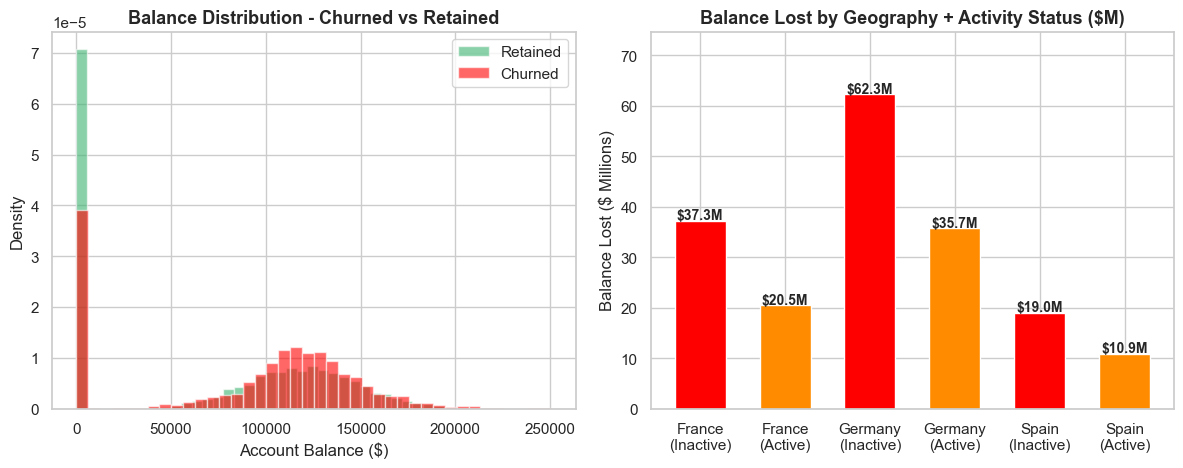

Chart saved.


In [8]:
# ANALYSIS 7: Balance at Risk - putting a dollar number on everything
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Balance distribution - churned vs retained
axes[0].hist(df[df['Exited']==0]['Balance'], bins=40, alpha=0.6,
             color='Mediumseagreen', label='Retained', density=True)
axes[0].hist(df[df['Exited']==1]['Balance'], bins=40, alpha=0.6,
             color='Red', label='Churned', density=True)
axes[0].set_title('Balance Distribution - Churned vs Retained')
axes[0].set_xlabel('Account Balance ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Revenue at risk by geography + active status
risk_group = df[df['Exited']==1].groupby(
    ['Geography', 'IsActiveMember'])['Balance'].sum() / 1e6
risk_df = risk_group.reset_index()
risk_df['Segment'] = risk_df['Geography'] + '\n' + \
    risk_df['IsActiveMember'].map({0: '(Inactive)', 1: '(Active)'})
colors_risk = ['Red' if x == 0 else 'Darkorange' 
               for x in risk_df['IsActiveMember']]
bars = axes[1].bar(risk_df['Segment'], risk_df['Balance'],
                    color=colors_risk, width=0.6)
axes[1].set_title('Balance Lost by Geography + Activity Status ($M)')
axes[1].set_ylabel('Balance Lost ($ Millions)')
axes[1].set_ylim(0, risk_df['Balance'].max() * 1.2)
for bar, val in zip(bars, risk_df['Balance']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${val:.1f}M', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../dashboard/07_balance_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [9]:
# SUMMARY TABLE - all 7 findings in one place
print("=" * 60)
print("   EDA COMPLETE — EXECUTIVE SUMMARY OF ALL FINDINGS")
print("=" * 60)

total_customers = len(df)
total_churned = df['Exited'].sum()
balance_lost = df[df['Exited']==1]['Balance'].sum()
germany_churn = df[df['Geography']=='Germany']['Exited'].mean()*100
france_churn = df[df['Geography']=='France']['Exited'].mean()*100
prod3_churn = df[df['NumOfProducts']==3]['Exited'].mean()*100
complain_churn = df[df['Complain']==1]['Exited'].mean()*100
age_4560_churn = df[df['Age_Band']=='45–60']['Exited'].mean()*100
inactive_balance = df[(df['Exited']==1) & 
                      (df['IsActiveMember']==0)]['Balance'].sum()

print(f"\n  1. Overall churn rate      : 20.4% ({total_churned:,} customers)")
print(f"  2. Total balance lost      : ${balance_lost:,.0f}")
print(f"  3. Germany churn rate      : {germany_churn:.1f}% vs France {france_churn:.1f}%")
print(f"  4. 3-product churn rate    : {prod3_churn:.1f}% — product paradox")
print(f"  5. Complaint → churn rate  : {complain_churn:.1f}% — service failure")
print(f"  6. Age 45-60 churn rate    : {age_4560_churn:.1f}% — highest risk band")
print(f"  7. Inactive churner balance: ${inactive_balance:,.0f}")
print(f"\n KEY ACTION: Build complaint escalation system +")
print(f"   priority RM outreach for inactive 45-60 customers")
print("=" * 60)

   EDA COMPLETE — EXECUTIVE SUMMARY OF ALL FINDINGS

  1. Overall churn rate      : 20.4% (2,038 customers)
  2. Total balance lost      : $185,681,112
  3. Germany churn rate      : 32.4% vs France 16.2%
  4. 3-product churn rate    : 82.7% — product paradox
  5. Complaint → churn rate  : 99.5% — service failure
  6. Age 45-60 churn rate    : 51.1% — highest risk band
  7. Inactive churner balance: $118,560,444

 KEY ACTION: Build complaint escalation system +
   priority RM outreach for inactive 45-60 customers


### Analysis 7 — Business Insight

**Finding:** Churned customers hold significantly higher balances
than retained customers. The bank is not losing low-value accounts —
it is losing its best depositors.

Inactive churners (IsActiveMember = 0) account for the largest
share of balance lost across all three geographies.
Germany inactive churners alone represent a massive revenue hole.

**The single most important action the bank can take:**
Flag every customer who is: inactive + balance > $50,000 + age 45–60.
These customers have not complained yet — but they match the exact
profile of everyone who already left.

Call them before they become a complaint. That is the only
intervention window the bank has.

---

## EDA Complete — 7 Analyses, 7 Business Insights

| # | Analysis | Key Finding |
|---|----------|-------------|
| 1 | Overall Churn | 20.4% — $185M balance lost |
| 2 | Geography | Germany churns 2× France |
| 3 | Products | 3+ products = 82%+ churn |
| 4 | Complaint | 99.5% of complainers churned |
| 5 | Age Band | 45–60 highest risk segment |
| 6 | Card + Points | Not reliable predictors |
| 7 | Balance at Risk | Inactive customers = biggest loss |